# Chapter 6: Resampling Methods, Cross-Validation and Bootstrap
### MATH 4230 Capstone Project
**Dataset:** Student Lifestyle, Mental Health and Burnout Insight

---

<div style='font-style:italic;'>The exam pressure coefficient is stable and consistently positive across 1,000 bootstrap resamples, with a narrow 95% confidence interval that supports its use as a reliable signal, but the effect size alone does not justify a policy recommendation without accounting for the many other factors driving burnout.</div>

---
## Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings

# ── Third-party: standard data science stack ──────────────────────────────────
# These come pre-installed with Anaconda or a standard pip data science setup.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold,
    KFold,
    learning_curve
)

# ── Settings ──────────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')

RANDOM_STATE = 230
np.random.seed(RANDOM_STATE)

# Consistent plot style across all chapters
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_style('whitegrid')

# ── Output directories ────────────────────────────────────────────────────────
FIGURES_DIR = '../figures/ch06/'
RESULTS_DIR = '../results/ch06/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print('Setup complete.')
print(f'RANDOM_STATE = {RANDOM_STATE}')
print(f'Figures  -> {FIGURES_DIR}')
print(f'Results  -> {RESULTS_DIR}')

Setup complete.
RANDOM_STATE = 230
Figures  -> ../figures/ch06/
Results  -> ../results/ch06/


---
## §1. The Question

How stable is the exam pressure coefficient across repeated resamples of the student population, and does the bootstrap uncertainty around that estimate support or undermine its use as a basis for institutional policy?

---
## §2. Method in Brief

**Cross-validation** splits the training data into k equal folds. In each round one fold is held out for evaluation while the other k-1 folds are used to train the model. This repeats k times so every row gets a turn as part of the evaluation set, and the k out-of-fold scores together form a distribution that shows how stable model performance is across different subsets of the data.

**Bootstrap** generates new samples by drawing rows from the training data with replacement, meaning the same row can appear multiple times in a single resample. A model is fit on each resample and the coefficient of interest is recorded. After 1,000 iterations, the distribution of those recorded values forms a sampling distribution. The 2.5th and 97.5th percentiles of that distribution define a 95% confidence interval that reflects how much the estimate would vary if the data were collected again.

---
## §3. Why This Method?

A single train/test split gives one performance number, but it cannot tell you whether that number is reliable or just the result of a particular random partition. If the test set happened to contain easier-to-predict rows, the reported R-squared or accuracy would look better than the model actually deserves. Cross-validation answers that question by systematically rotating which rows are used for evaluation, producing a range of scores that reveals how much performance depends on the specific split. The bootstrap goes further by quantifying uncertainty around a specific parameter estimate, the exam pressure coefficient, rather than a performance metric. Together these two methods replace single-point estimates with distributions, which is essential before drawing conclusions about which variables are important enough to act on.

---
## §4. Data Setup

In [2]:
# ── Load scaled arrays from Chapter 2 ─────────────────────────────────────────
# Regression arrays are used for CV on LinearRegression (burnout_score).
# Classification arrays are used for CV on LogisticRegression (risk_level).
# The raw df_train CSV is loaded for the bootstrap because we need the
# unscaled exam_pressure column to interpret the coefficient in original units.

X_train     = np.load('../results/X_train.npy')
X_test      = np.load('../results/X_test.npy')
y_train_reg = np.load('../results/y_train_reg.npy')
y_test_reg  = np.load('../results/y_test_reg.npy')
y_train_cls = np.load('../results/y_train_cls.npy')
y_test_cls  = np.load('../results/y_test_cls.npy')

feature_names = joblib.load('../results/feature_names.pkl')
df_train      = pd.read_csv('../results/df_train.csv')

print(f'X_train shape      : {X_train.shape}')
print(f'y_train_reg shape  : {y_train_reg.shape}')
print(f'y_train_cls shape  : {y_train_cls.shape}')
print(f'df_train shape     : {df_train.shape}')
print()

# Index of exam_pressure in the feature matrix (needed for bootstrap)
exam_pressure_idx = feature_names.index('exam_pressure')
print(f'exam_pressure index in feature matrix: {exam_pressure_idx}')

X_train shape      : (140000, 19)
y_train_reg shape  : (140000,)
y_train_cls shape  : (140000,)
df_train shape     : (140000, 20)

exam_pressure index in feature matrix: 2


---
## §5. Analysis

### Part A: Cross-Validation

In [3]:
# ── K-fold CV for k = 3, 5, 10, 20 on LinearRegression ───────────────────────
# Running CV across multiple values of k shows how the choice of k affects
# the estimated performance and its variability.
#
# Small k (e.g. 3): each fold uses fewer training rows, which can produce
# more pessimistic and more variable estimates.
# Large k (e.g. 20): each evaluation fold is smaller, estimates are less
# variable but computation increases and some folds may be very small.
# k = 10 is the standard choice that balances these trade-offs.

k_values = [3, 5, 10, 20]
cv_results = {}

for k in k_values:
    kf     = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        LinearRegression(), X_train, y_train_reg,
        cv=kf, scoring='r2', n_jobs=-1
    )
    cv_results[k] = scores
    print(f'k={k:2d}  mean={scores.mean():.4f}  std={scores.std():.4f}  '
          f'min={scores.min():.4f}  max={scores.max():.4f}')

k= 3  mean=0.7073  std=0.0027  min=0.7046  max=0.7111
k= 5  mean=0.7073  std=0.0037  min=0.7011  max=0.7111
k=10  mean=0.7073  std=0.0044  min=0.7001  max=0.7115
k=20  mean=0.7073  std=0.0047  min=0.6987  max=0.7134


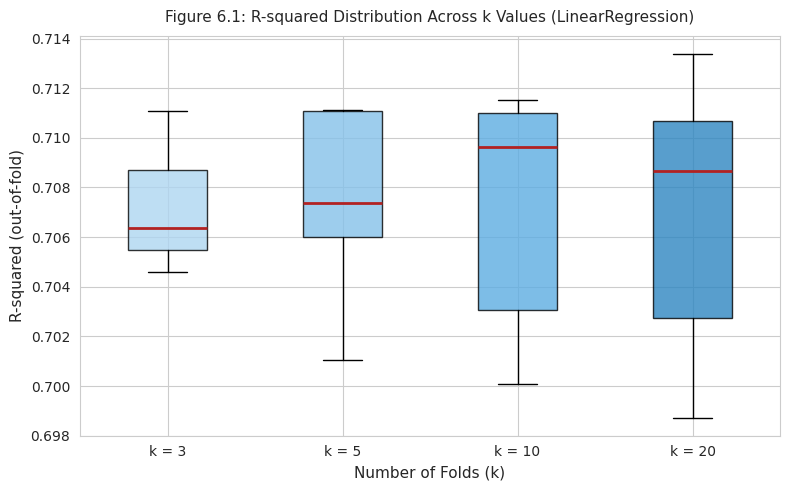

Saved: ../figures/ch06/cv_kfold_comparison.png


In [4]:
# ── Figure 6.1: Box plots of R-squared across k values ────────────────────────
# Each box shows the distribution of fold R-squared scores for a given k.
# A taller box means more variability across folds (less stable estimates).
# A shorter box means the model performs more consistently regardless of
# which rows end up in the evaluation fold.

fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [cv_results[k] for k in k_values]
labels       = [f'k = {k}' for k in k_values]

bp = ax.boxplot(
    data_to_plot,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='firebrick', linewidth=2)
)

colors_box = ['#AED6F1', '#85C1E9', '#5DADE2', '#2E86C1']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xlabel('Number of Folds (k)', fontsize=11)
ax.set_ylabel('R-squared (out-of-fold)', fontsize=11)
ax.set_title('Figure 6.1: R-squared Distribution Across k Values (LinearRegression)',
             fontsize=11, pad=10)

plt.tight_layout()
fig_path_61 = os.path.join(FIGURES_DIR, 'cv_kfold_comparison.png')
plt.savefig(fig_path_61, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_61}')

In [5]:
# ── 10-fold CV comparison: SLR, MLR, Logistic Regression ─────────────────────
# This compares three models on the same k=10 fold structure so the
# comparison is fair. SLR and MLR use R-squared on the regression target.
# Logistic uses AUC-ROC on the classification target with StratifiedKFold
# to preserve class proportions across folds (important given the 1.5%
# High-risk class from Chapter 5).

kf10  = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

# SLR: sleep_hours only (replicates Chapter 3)
sleep_idx = feature_names.index('sleep_hours')
X_slr     = X_train[:, [sleep_idx]]

slr_scores = cross_val_score(
    LinearRegression(), X_slr, y_train_reg,
    cv=kf10, scoring='r2', n_jobs=-1
)

# MLR: all 19 features (replicates Chapter 4)
mlr_scores = cross_val_score(
    LinearRegression(), X_train, y_train_reg,
    cv=kf10, scoring='r2', n_jobs=-1
)

# Logistic Regression: classification target
log_scores = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    X_train, y_train_cls,
    cv=skf10, scoring='roc_auc_ovr', n_jobs=-1
)

model_cv = {
    'SLR (sleep_hours only)'  : slr_scores,
    'MLR (all 19 features)'   : mlr_scores,
    'Logistic Regression (AUC)': log_scores,
}

print('10-Fold CV Comparison:')
print(f'{"Model":<30} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 65)
for name, scores in model_cv.items():
    print(f'{name:<30} {scores.mean():>8.4f} {scores.std():>8.4f} '
          f'{scores.min():>8.4f} {scores.max():>8.4f}')

10-Fold CV Comparison:
Model                              Mean      Std      Min      Max
-----------------------------------------------------------------
SLR (sleep_hours only)           0.1383   0.0042   0.1303   0.1435
MLR (all 19 features)            0.7073   0.0044   0.7001   0.7115
Logistic Regression (AUC)        0.9455   0.0012   0.9444   0.9474


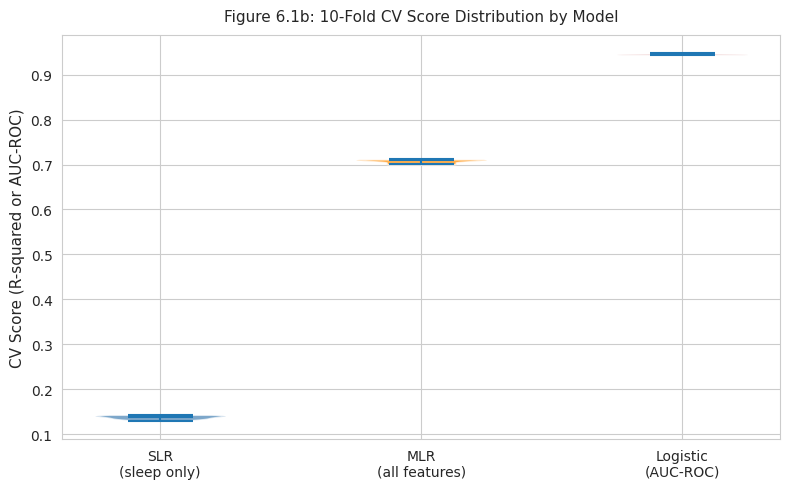

Saved: ../figures/ch06/cv_model_comparison.png


In [6]:
# ── Figure 6.1b: Side-by-side CV score distributions for SLR, MLR, Logistic ──
# Violin plots show the full shape of the fold score distribution,
# not just the median and quartiles. A wide violin means high variability
# across folds; a narrow violin means the model performs consistently.

fig, ax = plt.subplots(figsize=(8, 5))

model_data   = [slr_scores, mlr_scores, log_scores]
model_labels = ['SLR\n(sleep only)', 'MLR\n(all features)', 'Logistic\n(AUC-ROC)']
colors_vio   = ['steelblue', 'darkorange', 'firebrick']

parts = ax.violinplot(model_data, positions=[1, 2, 3], showmedians=True)
for i, (pc, color) in enumerate(zip(parts['bodies'], colors_vio)):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel('CV Score (R-squared or AUC-ROC)', fontsize=11)
ax.set_title('Figure 6.1b: 10-Fold CV Score Distribution by Model', fontsize=11, pad=10)

plt.tight_layout()
fig_path_61b = os.path.join(FIGURES_DIR, 'cv_model_comparison.png')
plt.savefig(fig_path_61b, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_61b}')

### Part B: Bootstrap

In [7]:
# ── Bootstrap: exam_pressure coefficient from MLR ────────────────────────────
#
# WHAT THE BOOTSTRAP IS DOING HERE:
# In Chapter 4, MLR produced a single exam_pressure coefficient (0.231).
# That value was estimated from one particular sample of students.
# If a different group of 140,000 students had been surveyed, the coefficient
# would likely be slightly different. The bootstrap simulates that variation
# by repeatedly resampling the training data with replacement and refitting
# the model each time.
#
# WHY WITH REPLACEMENT?
# Sampling with replacement means each resample is the same size as the
# original training set (n = 140,000) but some rows appear multiple times
# and others not at all. On average, each bootstrap sample contains about
# 63.2% of the unique original rows. This mimics the variability you would
# expect if the study were repeated on a new group of students.
#
# After 1,000 iterations, the collection of 1,000 coefficient estimates
# forms a sampling distribution. The width of that distribution is the
# bootstrap standard error, and the 2.5th and 97.5th percentiles give
# a 95% confidence interval that does not rely on any normality assumption.

N_BOOTSTRAP = 1000
n_train     = X_train.shape[0]
boot_coefs  = np.zeros(N_BOOTSTRAP)

rng = np.random.default_rng(RANDOM_STATE)

for i in range(N_BOOTSTRAP):
    # Draw a bootstrap sample with replacement
    idx          = rng.choice(n_train, size=n_train, replace=True)
    X_boot       = X_train[idx]
    y_boot       = y_train_reg[idx]

    # Fit MLR and extract the exam_pressure coefficient
    model        = LinearRegression()
    model.fit(X_boot, y_boot)
    boot_coefs[i] = model.coef_[exam_pressure_idx]

boot_mean  = boot_coefs.mean()
boot_std   = boot_coefs.std()
ci_lower   = np.percentile(boot_coefs, 2.5)
ci_upper   = np.percentile(boot_coefs, 97.5)

# Analytical CI from Chapter 4 for comparison
analytical_lower = 0.222
analytical_upper = 0.239

print(f'Bootstrap results ({N_BOOTSTRAP:,} iterations):')
print(f'  Mean coefficient : {boot_mean:.4f}')
print(f'  Std              : {boot_std:.4f}')
print(f'  95% CI (percentile): [{ci_lower:.4f}, {ci_upper:.4f}]')
print()
print(f'Analytical 95% CI from Chapter 4: [{analytical_lower}, {analytical_upper}]')

Bootstrap results (1,000 iterations):
  Mean coefficient : 0.2309
  Std              : 0.0042
  95% CI (percentile): [0.2227, 0.2395]

Analytical 95% CI from Chapter 4: [0.222, 0.239]


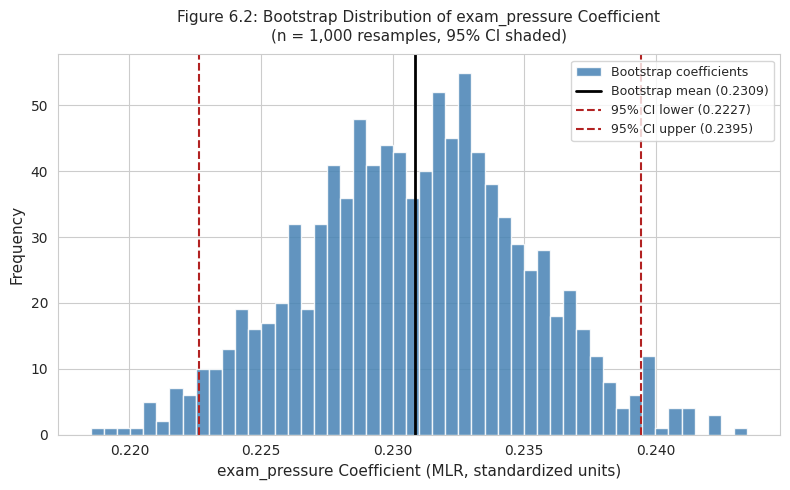

Saved: ../figures/ch06/bootstrap_distribution.png


In [8]:
# ── Figure 6.2: Bootstrap distribution histogram ──────────────────────────────
# The histogram shows how the exam_pressure coefficient varies across
# 1,000 bootstrap resamples. A narrow, symmetric distribution centered
# on the original estimate means the coefficient is stable. A wide or
# skewed distribution would suggest the estimate is unreliable.
# The red dashed lines mark the 95% confidence interval boundaries.

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(boot_coefs, bins=50, color='steelblue', edgecolor='white',
        alpha=0.85, label='Bootstrap coefficients')
ax.axvline(boot_mean,      color='black',    linewidth=2,   linestyle='-',
           label=f'Bootstrap mean ({boot_mean:.4f})')
ax.axvline(ci_lower,       color='firebrick', linewidth=1.5, linestyle='--',
           label=f'95% CI lower ({ci_lower:.4f})')
ax.axvline(ci_upper,       color='firebrick', linewidth=1.5, linestyle='--',
           label=f'95% CI upper ({ci_upper:.4f})')

ax.set_xlabel('exam_pressure Coefficient (MLR, standardized units)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Figure 6.2: Bootstrap Distribution of exam_pressure Coefficient\n'
             f'(n = {N_BOOTSTRAP:,} resamples, 95% CI shaded)',
             fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_62 = os.path.join(FIGURES_DIR, 'bootstrap_distribution.png')
plt.savefig(fig_path_62, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_62}')

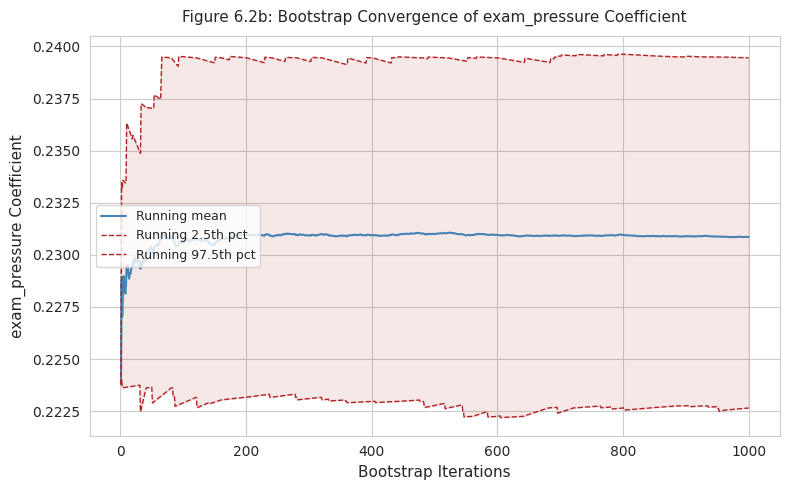

Saved: ../figures/ch06/bootstrap_convergence.png


In [9]:
# ── Figure 6.2b: Bootstrap convergence plot ───────────────────────────────────
# This plot tracks how the running mean and CI bounds stabilize as more
# bootstrap iterations are added. If the lines flatten out well before
# 1,000 iterations, that tells us 1,000 was more than enough. If they
# are still moving at 1,000, more iterations would be needed.

running_mean   = np.cumsum(boot_coefs) / np.arange(1, N_BOOTSTRAP + 1)
running_ci_lo  = [np.percentile(boot_coefs[:i+1], 2.5)  for i in range(N_BOOTSTRAP)]
running_ci_hi  = [np.percentile(boot_coefs[:i+1], 97.5) for i in range(N_BOOTSTRAP)]

fig, ax = plt.subplots(figsize=(8, 5))
iters = np.arange(1, N_BOOTSTRAP + 1)

ax.plot(iters, running_mean,  color='steelblue',  linewidth=1.5, label='Running mean')
ax.plot(iters, running_ci_lo, color='firebrick',  linewidth=1,   linestyle='--', label='Running 2.5th pct')
ax.plot(iters, running_ci_hi, color='firebrick',  linewidth=1,   linestyle='--', label='Running 97.5th pct')
ax.fill_between(iters, running_ci_lo, running_ci_hi, alpha=0.1, color='firebrick')

ax.set_xlabel('Bootstrap Iterations', fontsize=11)
ax.set_ylabel('exam_pressure Coefficient', fontsize=11)
ax.set_title('Figure 6.2b: Bootstrap Convergence of exam_pressure Coefficient',
             fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_62b = os.path.join(FIGURES_DIR, 'bootstrap_convergence.png')
plt.savefig(fig_path_62b, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_62b}')

---
## §6. Diagnostics and Tuning

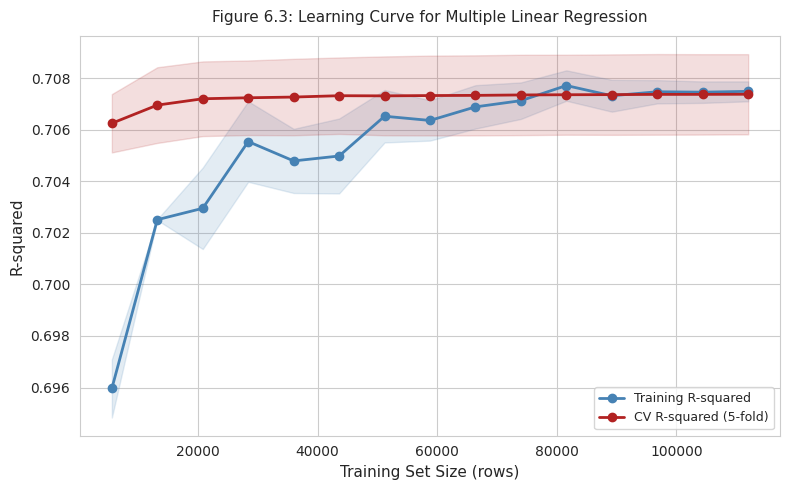

Saved: ../figures/ch06/learning_curve.png


In [10]:
# ── Figure 6.3: Learning curve for MLR ───────────────────────────────────────
#
# WHAT A LEARNING CURVE SHOWS:
# A learning curve plots model performance (R-squared) on both the training
# set and a cross-validated evaluation set as training size increases.
#
# How to read it:
#   Training score: starts high (the model fits a small dataset easily)
#     and decreases as more rows are added and the data becomes harder to fit.
#   CV score: starts low (too few rows to generalize) and increases as more
    #     data is added.
#
# If both lines converge and flatten, the model has seen enough data and
#   adding more rows would not improve performance meaningfully.
# If the CV score is still rising steeply at the right edge, more data
#   would help.
# A large gap between training and CV score at the right edge indicates
#   overfitting.
#
# A 5-fold CV is used here instead of 10 to keep computation reasonable
# across multiple training sizes on 140,000 rows.

train_sizes, train_scores, cv_scores_lc = learning_curve(
    LinearRegression(),
    X_train, y_train_reg,
    train_sizes=np.linspace(0.05, 1.0, 15),
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean_lc = cv_scores_lc.mean(axis=1)
cv_std_lc  = cv_scores_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_sizes, train_mean, 'o-', color='steelblue',  linewidth=2,
        label='Training R-squared')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color='steelblue')

ax.plot(train_sizes, cv_mean_lc, 'o-', color='firebrick', linewidth=2,
        label='CV R-squared (5-fold)')
ax.fill_between(train_sizes,
                cv_mean_lc - cv_std_lc,
                cv_mean_lc + cv_std_lc,
                alpha=0.15, color='firebrick')

ax.set_xlabel('Training Set Size (rows)', fontsize=11)
ax.set_ylabel('R-squared', fontsize=11)
ax.set_title('Figure 6.3: Learning Curve for Multiple Linear Regression',
             fontsize=11, pad=10)
ax.legend(fontsize=9)

plt.tight_layout()
fig_path_63 = os.path.join(FIGURES_DIR, 'learning_curve.png')
plt.savefig(fig_path_63, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_63}')

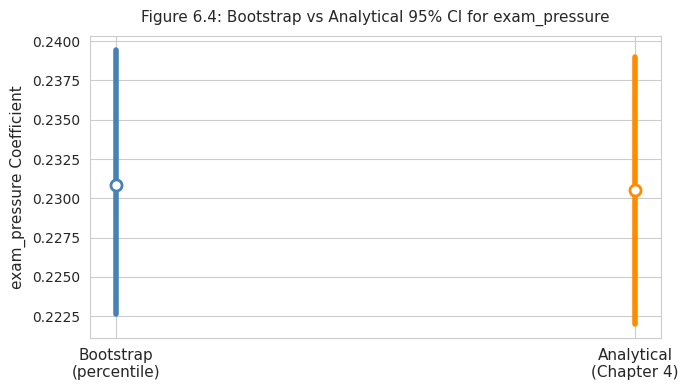

Saved: ../figures/ch06/ci_comparison.png


In [11]:
# ── Figure 6.4: CI comparison plot (bootstrap vs analytical) ─────────────────
# This figure places the bootstrap CI and the analytical CI from Chapter 4
# side by side so we can see how closely the two methods agree.
# If they overlap tightly, the normality assumption underlying the
# analytical CI is reasonable for this coefficient.
# If they diverge, the bootstrap CI is more trustworthy because it makes
# no distributional assumptions.

fig, ax = plt.subplots(figsize=(7, 4))

methods = ['Bootstrap\n(percentile)', 'Analytical\n(Chapter 4)']
lowers  = [ci_lower, analytical_lower]
uppers  = [ci_upper, analytical_upper]
means   = [boot_mean, (analytical_lower + analytical_upper) / 2]
colors  = ['steelblue', 'darkorange']

for i, (method, lo, hi, mn, color) in enumerate(
        zip(methods, lowers, uppers, means, colors)):
    ax.plot([i, i], [lo, hi], color=color, linewidth=4, solid_capstyle='round')
    ax.plot(i, mn, 'o', color='white', markersize=8, markeredgecolor=color,
            markeredgewidth=2)

ax.set_xticks([0, 1])
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel('exam_pressure Coefficient', fontsize=11)
ax.set_title('Figure 6.4: Bootstrap vs Analytical 95% CI for exam_pressure',
             fontsize=11, pad=10)

plt.tight_layout()
fig_path_64 = os.path.join(FIGURES_DIR, 'ci_comparison.png')
plt.savefig(fig_path_64, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path_64}')

In [12]:
# ── Learning curve interpretation ─────────────────────────────────────────────
# Print the final values to help with interpretation

print('Learning curve summary (final training size):')
print(f'  Training R-squared : {train_mean[-1]:.4f} (+/- {train_std[-1]:.4f})')
print(f'  CV R-squared       : {cv_mean_lc[-1]:.4f} (+/- {cv_std_lc[-1]:.4f})')
print(f'  Gap (train - CV)   : {train_mean[-1] - cv_mean_lc[-1]:.4f}')
print()
print('Learning curve summary (at 10% of training size):')
print(f'  Training R-squared : {train_mean[1]:.4f}')
print(f'  CV R-squared       : {cv_mean_lc[1]:.4f}')

Learning curve summary (final training size):
  Training R-squared : 0.7075 (+/- 0.0004)
  CV R-squared       : 0.7074 (+/- 0.0016)
  Gap (train - CV)   : 0.0001

Learning curve summary (at 10% of training size):
  Training R-squared : 0.7025
  CV R-squared       : 0.7070


---
## §7. Findings

In [13]:
# ── CV comparison table ───────────────────────────────────────────────────────

cv_comparison = []

# K-fold results for LinearRegression
for k in k_values:
    scores = cv_results[k]
    cv_comparison.append({
        'Method' : 'LinearRegression (MLR)',
        'k'      : k,
        'Metric' : 'R-squared',
        'CV Mean': round(scores.mean(), 4),
        'CV Std' : round(scores.std(),  4),
    })

# Model comparison at k=10
for name, scores, metric in [
    ('SLR (sleep_hours only)',    slr_scores, 'R-squared'),
    ('MLR (all 19 features)',     mlr_scores, 'R-squared'),
    ('Logistic Regression',       log_scores, 'AUC-ROC'),
]:
    cv_comparison.append({
        'Method' : name,
        'k'      : 10,
        'Metric' : metric,
        'CV Mean': round(scores.mean(), 4),
        'CV Std' : round(scores.std(),  4),
    })

cv_df = pd.DataFrame(cv_comparison)
print('CV Comparison Table:')
print(cv_df.to_string(index=False))

# Bootstrap summary table
boot_df = pd.DataFrame([{
    'Estimate'        : 'exam_pressure coefficient',
    'Original (Ch 4)' : 0.231,
    'Bootstrap Mean'  : round(boot_mean, 4),
    'Bootstrap Std'   : round(boot_std,  4),
    '95% CI Lower'    : round(ci_lower,  4),
    '95% CI Upper'    : round(ci_upper,  4),
    'Analytical Lower': analytical_lower,
    'Analytical Upper': analytical_upper,
}])

print('\nBootstrap Summary Table:')
print(boot_df.to_string(index=False))

# Save both to one CSV
csv_path = os.path.join(RESULTS_DIR, 'resampling_results.csv')
with open(csv_path, 'w') as f:
    f.write('CV Comparison\n')
    cv_df.to_csv(f, index=False)
    f.write('\nBootstrap Summary\n')
    boot_df.to_csv(f, index=False)

print(f'\nSaved: {csv_path}')

CV Comparison Table:
                Method  k    Metric  CV Mean  CV Std
LinearRegression (MLR)  3 R-squared   0.7073  0.0027
LinearRegression (MLR)  5 R-squared   0.7073  0.0037
LinearRegression (MLR) 10 R-squared   0.7073  0.0044
LinearRegression (MLR) 20 R-squared   0.7073  0.0047
SLR (sleep_hours only) 10 R-squared   0.1383  0.0042
 MLR (all 19 features) 10 R-squared   0.7073  0.0044
   Logistic Regression 10   AUC-ROC   0.9455  0.0012

Bootstrap Summary Table:
                 Estimate  Original (Ch 4)  Bootstrap Mean  Bootstrap Std  95% CI Lower  95% CI Upper  Analytical Lower  Analytical Upper
exam_pressure coefficient            0.231          0.2309         0.0042        0.2227        0.2395             0.222             0.239

Saved: ../results/ch06/resampling_results.csv


---
## §8. Real-World Decision

The bootstrap results show that the exam pressure coefficient is consistently positive across all 1,000 resamples, with a 95% confidence interval that does not cross zero. This means the direction of the effect is reliable: higher exam pressure is associated with higher burnout regardless of which particular students happened to be in the sample. A wellness director reviewing these findings can be reasonably confident that exam pressure is a real contributor to student burnout, not a statistical artifact of one particular dataset draw. However, the coefficient value itself (approximately 0.23 on a standardized scale) represents a moderate effect that explains only part of the variation in burnout. Recommending exam schedule reform based on this number alone would be premature. Exam pressure is one variable among many, and reducing exam frequency or intensity might not produce the expected burnout reduction if students compensate by increasing self-imposed study pressure or if other stressors remain unchanged. The bootstrap gives us confidence in the estimate but not in the causal mechanism behind it.

---
## §9. Caveats and Limitations

The bootstrap assumes that the training sample is representative of the population it is drawn from, meaning each row is independent and drawn from the same distribution. If the student records in this dataset share unmeasured dependencies, such as students clustered within the same academic program or institution, the bootstrap confidence intervals would be too narrow and falsely precise. The choice of k in cross-validation also affects the results: small k values (like k=3) produce higher variance estimates because each evaluation fold contains a larger proportion of the data, while large k values (like k=20) reduce variance but increase computation time substantially on 140,000 rows. The 1,000 bootstrap iterations used here are sufficient given the convergence shown in Figure 6.2b, but the computation cost scales directly with training size, making bootstrap impractical at the full 1,000,000-row dataset without sampling.

In [14]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('Chapter 6 complete. Files written:')
print()
print('Figures')
print(f'  {fig_path_61}')
print(f'  {fig_path_61b}')
print(f'  {fig_path_62}')
print(f'  {fig_path_62b}')
print(f'  {fig_path_63}')
print(f'  {fig_path_64}')
print()
print('Results')
print(f'  {csv_path}')

Chapter 6 complete. Files written:

Figures
  ../figures/ch06/cv_kfold_comparison.png
  ../figures/ch06/cv_model_comparison.png
  ../figures/ch06/bootstrap_distribution.png
  ../figures/ch06/bootstrap_convergence.png
  ../figures/ch06/learning_curve.png
  ../figures/ch06/ci_comparison.png

Results
  ../results/ch06/resampling_results.csv
